In [29]:
!pip install numpy matplotlib pandas seaborn scikit-learn

In [30]:
!pip install ucimlrepo

In [31]:
#import required library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#isolation forest
from sklearn.ensemble import IsolationForest
from ucimlrepo import fetch_ucirepo

In [38]:
air_quality = fetch_ucirepo(id=360)# in uci repository id of air quality dataset is 360

In [39]:
air_quality

{'data': {'ids': None,
  'features':            Date      Time  CO(GT)  PT08.S1(CO)  ...  PT08.S5(O3)     T    RH      AH
  0     3/10/2004  18:00:00     2.6         1360  ...         1268  13.6  48.9  0.7578
  1     3/10/2004  19:00:00     2.0         1292  ...          972  13.3  47.7  0.7255
  2     3/10/2004  20:00:00     2.2         1402  ...         1074  11.9  54.0  0.7502
  3     3/10/2004  21:00:00     2.2         1376  ...         1203  11.0  60.0  0.7867
  4     3/10/2004  22:00:00     1.6         1272  ...         1110  11.2  59.6  0.7888
  ...         ...       ...     ...          ...  ...          ...   ...   ...     ...
  9352   4/4/2005  10:00:00     3.1         1314  ...         1729  21.9  29.3  0.7568
  9353   4/4/2005  11:00:00     2.4         1163  ...         1269  24.3  23.7  0.7119
  9354   4/4/2005  12:00:00     2.4         1142  ...         1092  26.9  18.3  0.6406
  9355   4/4/2005  13:00:00     2.1         1003  ...          770  28.3  13.5  0.5139
  9356  

In [40]:
#coverting to dataframe
df = air_quality.data['features']

In [42]:
df=df[['CO(GT)','C6H6(GT)','NOx(GT)','NO2(GT)']]
df

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116
...,...,...,...,...
9352,3.1,13.5,472,190
9353,2.4,11.4,353,179
9354,2.4,12.4,293,175
9355,2.1,9.5,235,156


In [44]:
#parameters for isolation forest
n_estimators = 100 # number of trees in the forest
contamination = 0.01
sample_size =256

In [45]:
#training the isolation forest model
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=sample_size, random_state=42)

In [47]:
model.fit(df)
#predicting anomalies
anomaly_labels = model.predict(df)
#anomaly_labels will be -1 for anomalies and 1 for normal data points
#adding anomaly labels to the dataframe
df['anomaly'] = anomaly_labels 

In [48]:
df

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1
...,...,...,...,...,...
9352,3.1,13.5,472,190,1
9353,2.4,11.4,353,179,1
9354,2.4,12.4,293,175,1
9355,2.1,9.5,235,156,1


In [49]:
df['anomaly'].value_counts()

,count
anomaly,
1,9263
-1,94


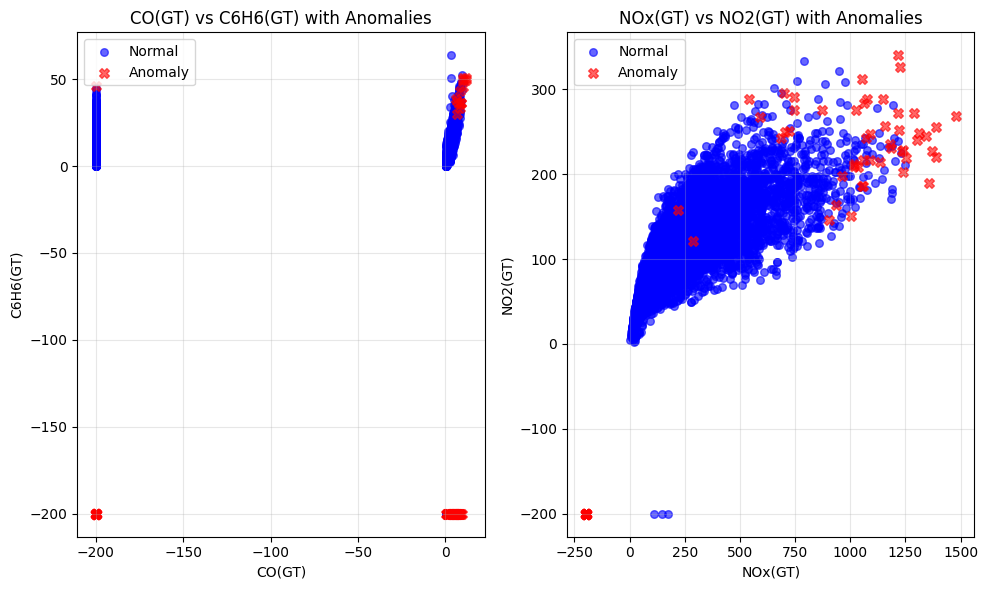

Number of normal data points: 9263
Number of anomalies detected: 94


In [51]:
fig,axes=plt.subplots(1,2,figsize=(10,6))
normal=df[df['anomaly']==1]
anomaly=df[df['anomaly']==-1]
axes[0].scatter(normal['CO(GT)'], normal['C6H6(GT)'], color='blue', label='Normal',alpha=0.6,s=30)
axes[0].scatter(anomaly['CO(GT)'], anomaly['C6H6(GT)'], color='red', label='Anomaly',alpha=0.6,s=50,marker='X')
axes[0].set_xlabel('CO(GT)')
axes[0].set_ylabel('C6H6(GT)')
axes[0].set_title('CO(GT) vs C6H6(GT) with Anomalies')
axes[0].legend()
axes[0].grid(True,alpha=0.3)

axes[1].scatter(normal['NOx(GT)'], normal['NO2(GT)'], color='blue', label='Normal',alpha=0.6,s=30)
axes[1].scatter(anomaly['NOx(GT)'], anomaly['NO2(GT)'], color='red', label='Anomaly',alpha=0.6,s=50,marker='X')
axes[1].set_xlabel('NOx(GT)')
axes[1].set_ylabel('NO2(GT)')
axes[1].set_title('NOx(GT) vs NO2(GT) with Anomalies')
axes[1].legend()
axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Number of normal data points: {len(normal)}")
print(f"Number of anomalies detected: {len(anomaly)}")


In [56]:
# saved model same folder
import joblib
model_path= 'C:\\Users\\Jyothi murali\\Desktop\\tekworks\\Anomaly Detection\\isolation_forest_model.pkl'
joblib.dump(model, model_path)

['C:\\Users\\Jyothi murali\\Desktop\\tekworks\\Anomaly Detection\\isolation_forest_model.pkl']